# Chapter 8 Lab — Valid and Invalid Inferences (Python)

In this lab you will reproduce several of the "statistical lies" simulations that accompany the book: situations in which perfectly standard brain-mapping analyses give badly misleading answers. In every exercise you generate the data yourself, so you know the ground truth — and you can watch thresholding, voxel selection, and circular analysis distort it. We finish with the diagnostic-testing arithmetic from Box 8.1.

**How to run this notebook.** Everything uses simulated data and runs in a few seconds with only numpy, scipy, and matplotlib — it works in the browser (JupyterLite/Pyodide), on [Google Colab](https://colab.research.google.com/), or locally. Run cells top to bottom. When you are done, head back to the [chapter page](../ch08-valid-and-invalid-inferences.md).

*Simulations adapted from the CANlab `FMRI_simulations` repository (github.com/canlab), `Principles_of_fMRI_statistical_lies`.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})


def one_sample_t(data):
    """Column-wise one-sample t-test. data: (N subjects, n voxels). Returns d_hat, t, p."""
    N = data.shape[0]
    d_hat = data.mean(axis=0) / data.std(axis=0, ddof=1)   # Cohen's d estimate per voxel
    t = d_hat * np.sqrt(N)
    p = 2 * stats.t.sf(np.abs(t), N - 1)
    return d_hat, t, p

## Lie 1 — The winner's curse: thresholding inflates effect sizes

Every voxel in this simulation has the **same true effect**, Cohen's $d = 0.5$ — a moderate effect, and a generous one for fMRI. We measure it in $N = 30$ participants, so each voxel's *estimated* $d$ scatters around 0.5 with noise. Then we do what every brain-mapping analysis does: keep only the voxels significant at p < .001.

Because significance requires the *estimated* effect to clear a bar (here $d > 0.62$), the surviving voxels are precisely the ones where noise pushed the estimate up. Selection does all the damage — no individual test is wrong.

p < 0.001   ->  4177 of 20000 voxels significant | mean estimated d among them: 0.799  (truth: 0.5)
p < 0.0001  ->  1336 of 20000 voxels significant | mean estimated d among them: 0.938  (truth: 0.5)


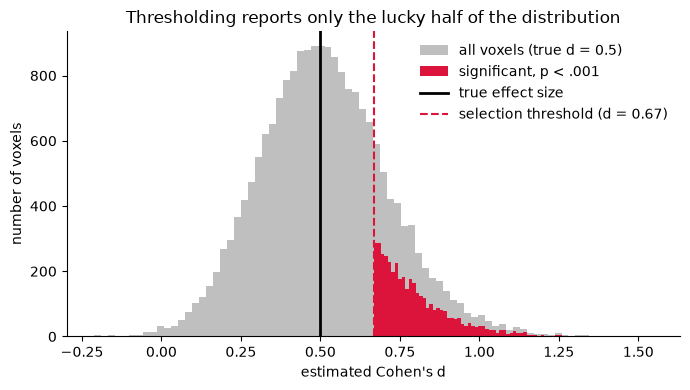

In [2]:
rng = np.random.default_rng(1)
N, n_vox, d_true = 30, 20_000, 0.5

data = rng.standard_normal((N, n_vox)) + d_true      # every voxel truly active at d = 0.5
d_hat, t, p = one_sample_t(data)

for alpha in [0.001, 0.0001]:
    sig = p < alpha
    print(f"p < {alpha:<7} -> {sig.sum():5d} of {n_vox} voxels significant | "
          f"mean estimated d among them: {d_hat[sig].mean():.3f}  (truth: {d_true})")

# Visualize the selection
d_min = stats.t.ppf(1 - 0.001 / 2, N - 1) / np.sqrt(N)   # minimum d needed for p < .001
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(d_hat, bins=80, color='0.75', label='all voxels (true d = 0.5)')
ax.hist(d_hat[p < 0.001], bins=80, color='crimson', label='significant, p < .001')
ax.axvline(d_true, color='k', lw=2, label='true effect size')
ax.axvline(d_min, color='crimson', ls='--', lw=1.5, label=f'selection threshold (d = {d_min:.2f})')
ax.set(xlabel="estimated Cohen's d", ylabel='number of voxels',
       title='Thresholding reports only the lucky half of the distribution')
ax.legend(frameon=False)
plt.tight_layout()

**What happened.** All 20,000 voxels are equally, truly active — yet the "significant" ones report an average $d \approx 0.75$, a ~50% overstatement, and stricter correction (p < .0001) makes the inflation *worse*, because it raises the bar that noise must help the estimate clear. This is why effect sizes read off significant voxels in small studies cannot be taken at face value, and why initially spectacular findings "decline" upon replication: later estimates simply regress to the true population value. Note also the miss rate — most truly active voxels did not survive the threshold at all (the power problem from Section 8.3).

## Lie 2 — Null brain–behavior correlations that look spectacular

Now for the "voodoo correlations" scenario. We simulate $N = 20$ participants with a behavioral score and 10,000 voxels of **pure noise — the true brain–behavior correlation is exactly zero everywhere**. Then we search the whole "brain" for voxels correlated with behavior and, as many papers once did, plot the best one.

Best voxel out of 10000: r = 0.79, p = 0.00003 (uncorrected)
Voxels with |r| > 0.5: 243   |r| > 0.6: 52


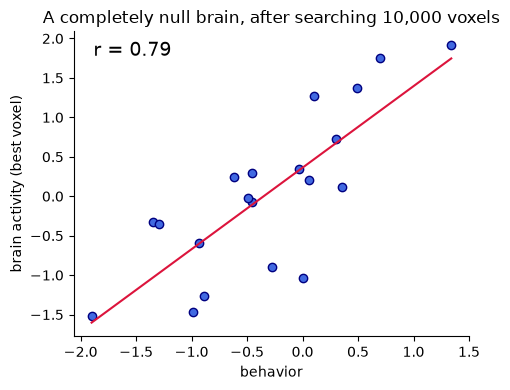

In [3]:
rng = np.random.default_rng(7)
N, n_vox = 20, 10_000

behavior = rng.standard_normal(N)                     # behavioral scores
brain = rng.standard_normal((N, n_vox))               # NULL data: no true correlation anywhere

# Vectorized Pearson correlation of behavior with every voxel
zb = (behavior - behavior.mean()) / behavior.std(ddof=1)
zx = (brain - brain.mean(0)) / brain.std(0, ddof=1)
r = zb @ zx / (N - 1)

best = np.argmax(np.abs(r))
r_best = r[best]
t_best = r_best * np.sqrt((N - 2) / (1 - r_best**2))
p_best = 2 * stats.t.sf(abs(t_best), N - 2)

print(f"Best voxel out of {n_vox}: r = {r_best:.2f}, p = {p_best:.5f} (uncorrected)")
print(f"Voxels with |r| > 0.5: {(np.abs(r) > .5).sum()}   |r| > 0.6: {(np.abs(r) > .6).sum()}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(behavior, brain[:, best], 'o', color='navy', mfc='royalblue')
m, b = np.polyfit(behavior, brain[:, best], 1)
xs = np.array([behavior.min(), behavior.max()])
ax.plot(xs, m * xs + b, '-', color='crimson')
ax.text(0.05, 0.92, f'r = {r_best:.2f}', transform=ax.transAxes, fontsize=14)
ax.set(xlabel='behavior', ylabel='brain activity (best voxel)',
       title='A completely null brain, after searching 10,000 voxels')
plt.tight_layout()

That scatterplot would look terrific in a paper — and it is 100% noise. Searching many voxels guarantees that some show large sample correlations by chance, and plotting or reporting the correlation *in the selected voxel* is circular. How bad the problem is depends on sample size: with small $N$, sample correlations are wildly variable, so the maximum across the brain is huge.

Mean max |r| by N: {10: np.float64(0.93), 20: np.float64(0.79), 40: np.float64(0.59), 100: np.float64(0.39)}


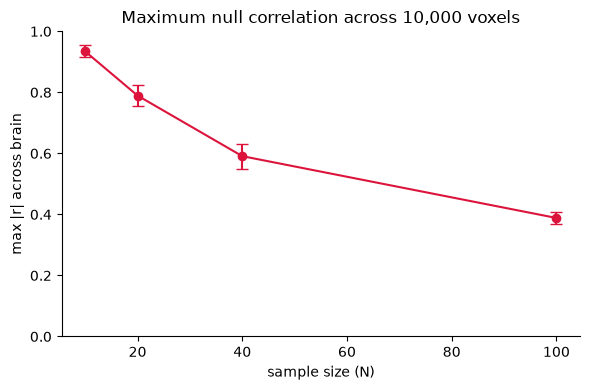

In [4]:
N_vals = [10, 20, 40, 100]
n_iter, n_vox = 20, 10_000
rmax = np.zeros((n_iter, len(N_vals)))

for j, N in enumerate(N_vals):
    for i in range(n_iter):
        beh = rng.standard_normal(N)
        brn = rng.standard_normal((N, n_vox))
        zb = (beh - beh.mean()) / beh.std(ddof=1)
        zx = (brn - brn.mean(0)) / brn.std(0, ddof=1)
        rmax[i, j] = np.abs(zb @ zx / (N - 1)).max()

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(N_vals, rmax.mean(0), yerr=rmax.std(0), marker='o', color='crimson', capsize=4)
ax.set(xlabel='sample size (N)', ylabel='max |r| across brain',
       title='Maximum null correlation across 10,000 voxels', ylim=(0, 1))
ax.axhline(0, color='k', lw=0.5)
plt.tight_layout()
print('Mean max |r| by N:', dict(zip(N_vals, rmax.mean(0).round(2))))

**What happened.** With $N = 10$–20, the best null voxel routinely shows $|r| > 0.7$ — the range of many celebrated brain–behavior correlations from small studies. Larger samples shrink the noise ceiling, which is one reason the field has moved toward much larger $N$ for individual-differences questions. The valid alternatives: report correlations from *independent* data (voxels selected in one sample, correlation estimated in another), or use predictive models tested on held-out participants.

## Lie 3 — Artifacts masquerade as signal

The map does not know physiology. A t-test lights up any *consistent* effect — whether it comes from neurons or from pulsating ventricles, draining veins, or task-correlated head motion. Here we build a 2-D "brain slice" with a genuine neural response (moderate, $d = 0.5$) and an artifact along the ventricle border producing a *stronger* consistent signal ($d = 1.2$). Then we threshold, as usual.

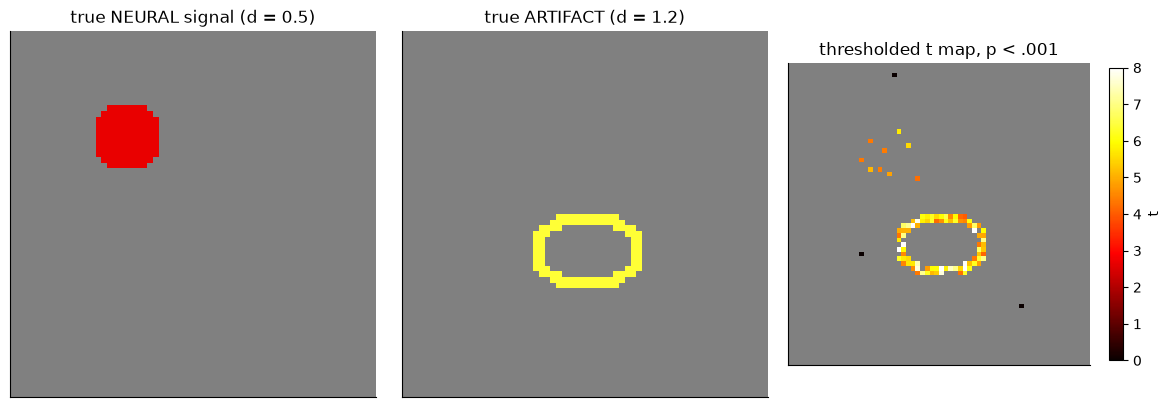

In [5]:
rng = np.random.default_rng(3)
size, N = 64, 20
yy, xx = np.mgrid[0:size, 0:size]

# A genuine neural region: a circle in "cortex"
neural = ((xx - 20)**2 + (yy - 18)**2 < 36).astype(float) * 0.5

# An artifact: a bright rim around the "ventricles" (center of the slice)
in_vent  = ((xx - 32)**2 / 64 + (yy - 38)**2 / 25) < 1
in_rim   = ((xx - 32)**2 / 100 + (yy - 38)**2 / 49) < 1
artifact = (in_rim & ~in_vent).astype(float) * 1.2

truth = neural + artifact
data = rng.standard_normal((N, size, size)) + truth        # N subjects
d_hat, t, p = one_sample_t(data.reshape(N, -1))
t_map = np.where(p < 0.001, t, np.nan).reshape(size, size)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in [(axes[0], np.where(neural > 0, neural, np.nan), 'true NEURAL signal (d = 0.5)'),
                       (axes[1], np.where(artifact > 0, artifact, np.nan), 'true ARTIFACT (d = 1.2)'),
                       (axes[2], t_map, 'thresholded t map, p < .001')]:
    ax.imshow(np.zeros((size, size)), cmap='gray', vmin=-1, vmax=1)
    im = ax.imshow(img, cmap='hot', vmin=0, vmax=8 if title.startswith('thr') else 1.5)
    ax.set(title=title, xticks=[], yticks=[])
fig.colorbar(im, ax=axes[2], shrink=0.8, label='t')
plt.tight_layout()

**What happened.** The thresholded map shows two "activations," and the artifact is the *bigger and more reliable* one. Nothing in the statistics distinguishes them — both are consistent non-zero effects. In real data, vascular and inflow artifacts and residual motion sit exactly where anatomy puts them, so a beautiful blob is not evidence of a neural response at that location. Defenses are physiological, not statistical: artifact-aware acquisition and preprocessing, nuisance modeling, checking effect locations against vascular anatomy, and skepticism about blobs in and around ventricles, edges, and large vessels.

## Lie 4 — A false double dissociation from circular ROI selection

The showpiece. Tasks A and B activate the brain **identically**: the same 500 truly active voxels, the same true effect ($d = 0.4$) in both tasks, in every voxel. With $N = 20$ and a p < .001 threshold, power is poor, so each task's map catches a different noise-driven subset of the true region.

Now we do what seems natural: define a "Task A region" from the A map and a "Task B region" from the B map, then extract each region's response to *both* tasks and plot the 2 × 2 pattern.

Task A map: 28 sig. voxels | Task B map: 27 sig. voxels | overlap: 1


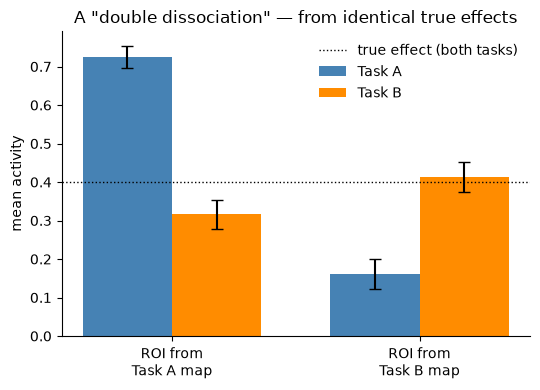

In [6]:
rng = np.random.default_rng(11)
N, n_vox, n_active, d_true = 20, 5000, 500, 0.4

truth = np.zeros(n_vox)
truth[:n_active] = d_true                      # same true map for BOTH tasks
taskA = rng.standard_normal((N, n_vox)) + truth
taskB = rng.standard_normal((N, n_vox)) + truth

_, _, pA = one_sample_t(taskA)
_, _, pB = one_sample_t(taskB)
roiA, roiB = pA < .001, pB < .001              # circular selection

print(f"Task A map: {roiA.sum()} sig. voxels | Task B map: {roiB.sum()} sig. voxels | "
      f"overlap: {(roiA & roiB).sum()}")

means = np.array([[taskA[:, roiA].mean(), taskB[:, roiA].mean()],
                  [taskA[:, roiB].mean(), taskB[:, roiB].mean()]])
sems  = np.array([[taskA[:, roiA].mean(1).std(ddof=1), taskB[:, roiA].mean(1).std(ddof=1)],
                  [taskA[:, roiB].mean(1).std(ddof=1), taskB[:, roiB].mean(1).std(ddof=1)]]) / np.sqrt(N)

x = np.arange(2)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(x - 0.18, means[:, 0], 0.36, yerr=sems[:, 0], capsize=4, label='Task A', color='steelblue')
ax.bar(x + 0.18, means[:, 1], 0.36, yerr=sems[:, 1], capsize=4, label='Task B', color='darkorange')
ax.set(xticks=x, xticklabels=['ROI from\nTask A map', 'ROI from\nTask B map'],
       ylabel='mean activity', title='A "double dissociation" — from identical true effects')
ax.axhline(d_true, color='k', ls=':', lw=1, label='true effect (both tasks)')
ax.legend(frameon=False)
plt.tight_layout()

A beautiful crossover: each region "prefers" its own task, and both bars overshoot the true effect. Low power means barely any overlap between the two maps ("Task A and Task B activate distinct regions!"), and circular extraction means each ROI carries noise favoring the task that selected it.

**The antidote is independence.** Select the ROIs in one half of the participants and measure the dissociation in the other half:

In [7]:
half = N // 2
_, _, pA1 = one_sample_t(taskA[:half])          # select ROIs on subjects 1–10 only
_, _, pB1 = one_sample_t(taskB[:half])
roiA1, roiB1 = pA1 < .01, pB1 < .01             # (slightly laxer threshold; half the data)

means_ind = np.array([[taskA[half:][:, roiA1].mean(), taskB[half:][:, roiA1].mean()],
                      [taskA[half:][:, roiB1].mean(), taskB[half:][:, roiB1].mean()]])

print("Independent test (subjects 11-20):")
print(f"  ROI from A: Task A = {means_ind[0,0]:.2f}, Task B = {means_ind[0,1]:.2f}")
print(f"  ROI from B: Task A = {means_ind[1,0]:.2f}, Task B = {means_ind[1,1]:.2f}")
print(f"  (true effect for both tasks everywhere active: {d_true})")

Independent test (subjects 11-20):
  ROI from A: Task A = 0.16, Task B = 0.13
  ROI from B: Task A = 0.11, Task B = 0.12
  (true effect for both tasks everywhere active: 0.4)


With independent selection and testing, the crossover vanishes: each ROI responds about equally to both tasks, and neither "prefers" the task that selected it — the dissociation was never real. (The means sit below the true $d = 0.4$ because selecting on only 10 subjects is noisy and admits some null voxels into the ROIs — the independent test is *unbiased*, not magically precise.) This is the general prescription from the chapter: any claim about the *strength* of a selected region's response, or a dissociation between regions, must be evaluated in data not used to select them (a different group, session, or held-out partition).

## Bonus — Box 8.1 in numbers: sensitivity, specificity, and PPV

Hypothesis tests care about sensitivity (power) and specificity, but *diagnostic* use of a test — "does this positive result mean the condition is present?" — also depends on the base rate. The positive predictive value is

$$PPV = \frac{\text{sens} \times \text{prev}}{\text{sens} \times \text{prev} + (1 - \text{spec})(1 - \text{prev})}.$$

Even an excellent test collapses for rare conditions.

sens=0.980 spec=0.980 prevalence=10.0%  ->  PPV = 0.84
sens=0.980 spec=0.980 prevalence= 1.0%  ->  PPV = 0.33
sens=0.980 spec=0.999 prevalence= 0.1%  ->  PPV = 0.50
sens=0.900 spec=0.900 prevalence=20.0%  ->  PPV = 0.69
sens=0.900 spec=0.800 prevalence=20.0%  ->  PPV = 0.53


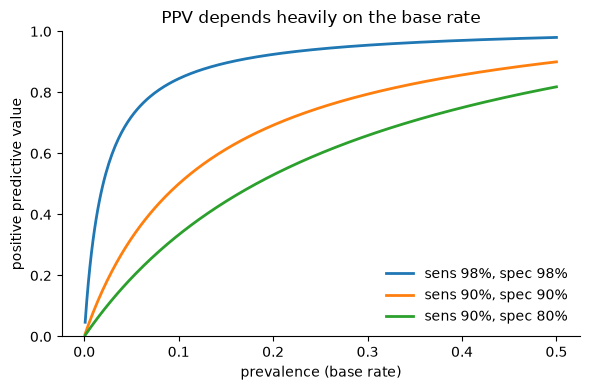

In [8]:
# Adapted from diagnostic_testing.m (github.com/canlab FMRI_simulations)
def ppv(sens, spec, prev):
    return sens * prev / (sens * prev + (1 - spec) * (1 - prev))

for sens, spec, prev in [(.98, .98, .10), (.98, .98, .01), (.98, .999, .001), (.90, .90, .20), (.90, .80, .20)]:
    print(f"sens={sens:.3f} spec={spec:.3f} prevalence={prev:>5.1%}  ->  PPV = {ppv(sens, spec, prev):.2f}")

prev_grid = np.linspace(0.001, 0.5, 300)
fig, ax = plt.subplots(figsize=(6, 4))
for sens, spec in [(.98, .98), (.90, .90), (.90, .80)]:
    ax.plot(prev_grid, ppv(sens, spec, prev_grid), lw=2, label=f'sens {sens:.0%}, spec {spec:.0%}')
ax.set(xlabel='prevalence (base rate)', ylabel='positive predictive value',
       title='PPV depends heavily on the base rate', ylim=(0, 1))
ax.legend(frameon=False)
plt.tight_layout()

**What happened.** With 98% sensitivity *and* specificity, a positive test for a condition affecting 1% of people is right only about a third of the time. This is why brain biomarkers need near-perfect specificity to be clinically useful for rare conditions, and why specificity against other patient groups (not just healthy controls) matters so much.

## Wrap-up

Four standard-looking analyses, four confident, wrong conclusions — from data where you knew the truth:

1. **Winner's curse:** thresholding guarantees inflated effect sizes among significant voxels; stricter correction inflates more.
2. **Null correlations:** searching many voxels in a small sample manufactures spectacular brain–behavior correlations from noise.
3. **Artifacts as signal:** the statistics cannot tell neural from non-neural consistency; physiology and preprocessing must.
4. **False double dissociations:** low power plus circular ROI extraction fabricates crossover interactions; independent selection and testing dissolves them.

The constructive lessons: pre-define regions or use held-out data for any effect size or dissociation claim, prefer predictive models evaluated on independent participants, use spatial statistics for location claims, and always ask what the base rate does to a "diagnostic" claim. Return to the [chapter page](../ch08-valid-and-invalid-inferences.md) for the thought questions and quiz.